In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedGroupKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, roc_curve

# load the feature CSV from preproc
_cwd = os.getcwd()
_root = os.path.dirname(_cwd) if os.path.basename(_cwd) == "EDA" else _cwd
DATA_CSV = os.path.join(_root, "data", "eegmat", "eegmat_bandpower_segments.csv")

df = pd.read_csv(DATA_CSV)

# quick sanity check on the data
print("Shape:", df.shape)
print("\nLabel counts (0 = baseline, 1 = task):")
print(df["label"].value_counts())
print("\nFirst few rows:")
df.head()

Shape: (4338, 68)

Label counts (0 = baseline, 1 = task):
label
0    3222
1    1116
Name: count, dtype: int64

First few rows:


,subject_id,recording_id,segment_idx,label,theta_EEG Fp1,theta_EEG Fp2,theta_EEG F3,theta_EEG F4,theta_EEG F7,theta_EEG F8,...,beta_EEG O1,beta_EEG O2,beta_EEG Fz,beta_EEG Cz,beta_EEG Pz,beta_EEG A2-A1,csp_1,csp_2,csp_3,csp_4
0,0,baseline,0,0,8.230781e-12,1.089378e-11,1.108751e-11,8.070233e-12,1.356126e-11,1.727897e-11,...,2.442675e-11,4.053214e-11,5.960407e-12,8.637142e-12,1.412838e-11,1.141470e-12,-0.562606,-1.661963,-0.642091,-0.988254
1,0,baseline,1,0,9.268282e-12,8.892937e-12,1.769324e-11,1.535522e-11,1.610250e-11,8.165809e-12,...,7.175125e-12,1.002375e-11,1.269855e-11,1.287391e-11,7.009352e-12,1.220406e-12,-1.547352,-1.030722,-0.680744,-0.121777
2,0,baseline,2,0,6.321962e-12,1.139815e-11,6.747887e-12,9.530494e-12,8.112675e-12,1.005060e-11,...,2.059991e-11,2.421764e-11,2.212177e-11,2.274492e-11,1.436223e-11,1.111232e-12,-1.293483,-0.351056,0.135325,0.157243
3,0,baseline,3,0,8.996813e-12,1.465802e-11,1.217375e-11,1.698796e-11,1.558309e-11,1.216414e-11,...,3.987606e-11,2.561226e-11,1.934992e-11,2.807244e-11,4.411119e-11,2.123295e-12,-0.492691,-0.933370,-0.525653,-0.159155
4,0,baseline,4,0,7.759277e-12,1.132600e-11,1.631360e-11,1.181184e-11,1.842302e-11,7.851705e-12,...,3.548510e-11,3.288838e-11,1.603332e-11,1.877462e-11,1.961471e-11,2.833497e-12,-0.603247,-1.209633,-0.257809,-0.409020


In [2]:
# separate out the metadata columns from the actual features
meta_cols = ["subject_id", "recording_id", "segment_idx", "label"]
feature_cols = [c for c in df.columns if c not in meta_cols]

# X = features, y = labels, groups = subject IDs (used to prevent leakage)
X = df[feature_cols].values
y = df["label"].values
groups = df["subject_id"].values

print("Number of features:", len(feature_cols))
print("Feature names sample:", feature_cols[:6])
print("\nX shape:", X.shape)
print("y shape:", y.shape)
print("Unique subjects:", len(np.unique(groups)))

Number of features: 64
Feature names sample: ['theta_EEG Fp1', 'theta_EEG Fp2', 'theta_EEG F3', 'theta_EEG F4', 'theta_EEG F7', 'theta_EEG F8']

X shape: (4338, 64)
y shape: (4338,)
Unique subjects: 36


In [3]:
# subject-level split so no subject leaks across train/test folds
cv = StratifiedGroupKFold(n_splits=5)

# this helper function trains a model and prints its cross-validated performance
def evaluate_model(name, model, X, y, groups):
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", model)
    ])
    
    # balanced accuracy is better than regular accuracy when classes are imbalanced
    bal_acc = cross_val_score(pipe, X, y, groups=groups, cv=cv, scoring="balanced_accuracy")
    auc = cross_val_score(pipe, X, y, groups=groups, cv=cv, scoring="roc_auc")
    
    print(f"{name:25s} | Balanced Acc: {bal_acc.mean():.3f} (+/- {bal_acc.std():.3f}) | AUC: {auc.mean():.3f} (+/- {auc.std():.3f})")
    return bal_acc, auc

print("Cross-validation setup ready (5-fold, subject-level split)")
print("Evaluation metric: Balanced Accuracy + AUC")

Cross-validation setup ready (5-fold, subject-level split)
Evaluation metric: Balanced Accuracy + AUC


In [4]:
# train and compare our three classifiers on Task 1: baseline vs task
print("=" * 55)
print("TASK 1: Baseline vs Task Classification")
print("=" * 55)

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "SVM":                 SVC(kernel="rbf", probability=True),
    "Random Forest":       RandomForestClassifier(n_estimators=100, random_state=42),
}

results = {}
for name, model in models.items():
    bal_acc, auc = evaluate_model(name, model, X, y, groups)
    results[name] = {"bal_acc": bal_acc, "auc": auc}

TASK 1: Baseline vs Task Classification
Logistic Regression       | Balanced Acc: 0.609 (+/- 0.046) | AUC: 0.705 (+/- 0.048)
SVM                       | Balanced Acc: 0.604 (+/- 0.033) | AUC: 0.723 (+/- 0.054)
Random Forest             | Balanced Acc: 0.604 (+/- 0.034) | AUC: 0.755 (+/- 0.052)


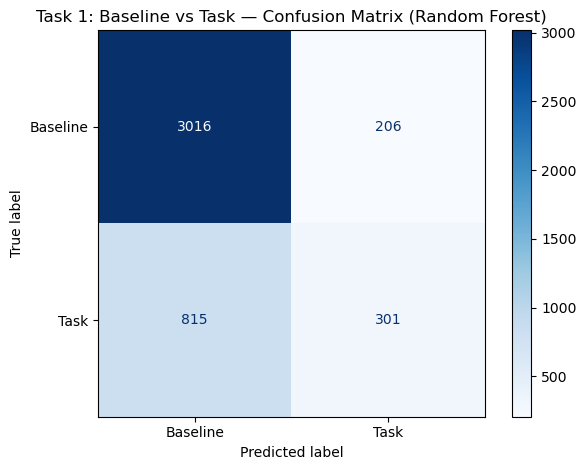


Classification Report:
              precision    recall  f1-score   support

    Baseline       0.79      0.94      0.86      3222
        Task       0.59      0.27      0.37      1116

    accuracy                           0.76      4338
   macro avg       0.69      0.60      0.61      4338
weighted avg       0.74      0.76      0.73      4338



In [5]:
# manually run CV folds to collect predictions for confusion matrix

best_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", RandomForestClassifier(n_estimators=100, random_state=42))
])

all_y_true = []
all_y_pred = []
all_y_prob = []

for train_idx, test_idx in cv.split(X, y, groups):
    best_pipe.fit(X[train_idx], y[train_idx])
    all_y_true.extend(y[test_idx])
    all_y_pred.extend(best_pipe.predict(X[test_idx]))
    all_y_prob.extend(best_pipe.predict_proba(X[test_idx])[:, 1])

# confusion matrix
cm = confusion_matrix(all_y_true, all_y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=["Baseline", "Task"])
disp.plot(cmap="Blues")
plt.title("Task 1: Baseline vs Task — Confusion Matrix (Random Forest)")
plt.tight_layout()
plt.show()

# full classification report
print("\nClassification Report:")
print(classification_report(all_y_true, all_y_pred, target_names=["Baseline", "Task"]))

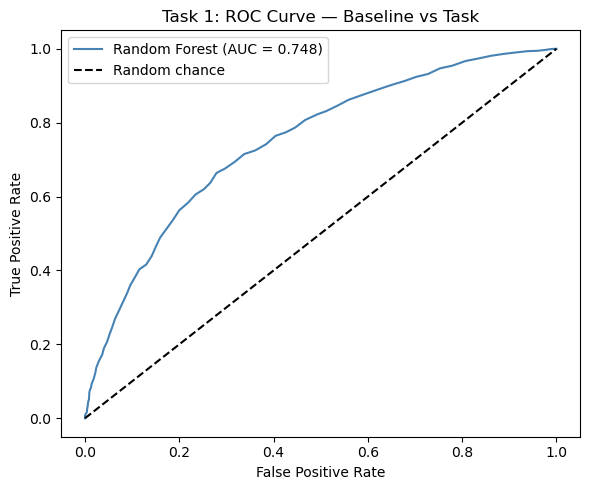

In [6]:
# plot the ROC curve to visualize overall classifier performance
fpr, tpr, _ = roc_curve(all_y_true, all_y_prob)
auc_score = roc_auc_score(all_y_true, all_y_prob)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color="steelblue", label=f"Random Forest (AUC = {auc_score:.3f})")
plt.plot([0, 1], [0, 1], "k--", label="Random chance")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Task 1: ROC Curve — Baseline vs Task")
plt.legend()
plt.tight_layout()
plt.show()

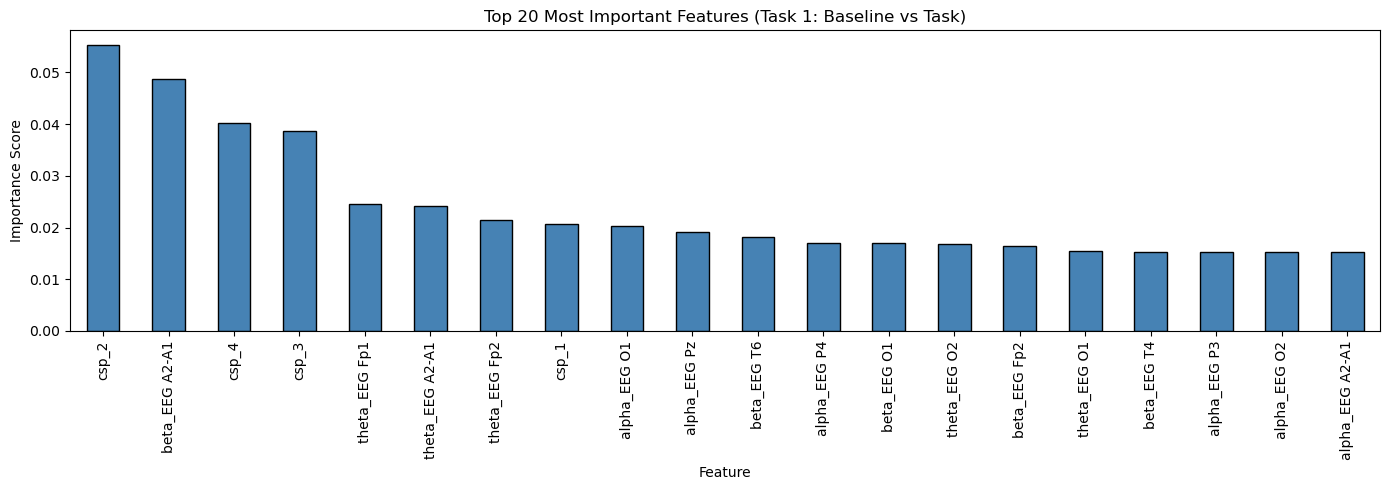


Total importance by band:
  theta     : 0.2721
  alpha     : 0.2676
  beta      : 0.3055
  csp       : 0.1548


In [7]:
# feature importance -- which bands/channels drive classification

# fit the model on the full dataset to get feature importances
pipe_fi = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", RandomForestClassifier(n_estimators=100, random_state=42))
])
pipe_fi.fit(X, y)

importances = pipe_fi.named_steps["clf"].feature_importances_
feat_imp = pd.Series(importances, index=feature_cols).sort_values(ascending=False)


feat_imp.head(20).plot(kind="bar", figsize=(14, 5), color="steelblue", edgecolor="black")
plt.title("Top 20 Most Important Features (Task 1: Baseline vs Task)")
plt.ylabel("Importance Score")
plt.xlabel("Feature")
plt.tight_layout()
plt.show()

# summarize importance by frequency band
print("\nTotal importance by band:")
for band in ["theta", "alpha", "beta", "csp"]:
    cols = [c for c in feature_cols if c.startswith(band)]
    if cols:
        print(f"  {band:10s}: {feat_imp[cols].sum():.4f}")

In [8]:
# Task 2: hard vs easy within task segments
# dataset doesn't have a hard/easy label so we define it using alpha power
# lower alpha = more mental effort = hard, higher alpha = easier
print("=" * 55)
print("TASK 2: Hard vs Easy (within Task segments only)")
print("=" * 55)

# keep only task segments
task_df = df[df["label"] == 1].copy()

# compute mean alpha power across all alpha channels for each segment
alpha_cols = [c for c in feature_cols if c.startswith("alpha_")]
task_df["mean_alpha"] = task_df[alpha_cols].mean(axis=1)

# for each subject, split their task segments into hard (low alpha) 
# and easy (high alpha) using their own median as the cutoff
# per-subject median so individual differences don't skew the split
subj_median = task_df.groupby("subject_id")["mean_alpha"].median()
task_df["hard_easy"] = task_df.apply(
    lambda row: 0 if row["mean_alpha"] <= subj_median[row["subject_id"]] else 1,
    axis=1
)
# label: 0 = hard (low alpha), 1 = easy (high alpha)

print("Hard/Easy segment counts:")
print(task_df["hard_easy"].value_counts())
print("\nSubjects:", task_df["subject_id"].nunique())

TASK 2: Hard vs Easy (within Task segments only)
Hard/Easy segment counts:
hard_easy
0    576
1    540
Name: count, dtype: int64

Subjects: 36


In [9]:
# set up features and labels for Task 2
X2 = task_df[feature_cols].values
y2 = task_df["hard_easy"].values
groups2 = task_df["subject_id"].values

# train and compare all three models on Task 2
print("Model performance on Task 2 (Hard vs Easy):\n")
results2 = {}
for name, model in models.items():
    bal_acc, auc = evaluate_model(name, model, X2, y2, groups2)
    results2[name] = {"bal_acc": bal_acc, "auc": auc}

Model performance on Task 2 (Hard vs Easy):

Logistic Regression       | Balanced Acc: 0.634 (+/- 0.018) | AUC: 0.717 (+/- 0.036)
SVM                       | Balanced Acc: 0.678 (+/- 0.030) | AUC: 0.730 (+/- 0.062)
Random Forest             | Balanced Acc: 0.713 (+/- 0.041) | AUC: 0.769 (+/- 0.050)


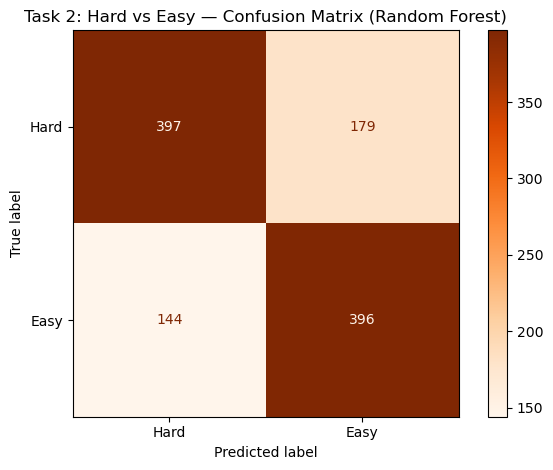


Classification Report:
              precision    recall  f1-score   support

        Hard       0.73      0.69      0.71       576
        Easy       0.69      0.73      0.71       540

    accuracy                           0.71      1116
   macro avg       0.71      0.71      0.71      1116
weighted avg       0.71      0.71      0.71      1116



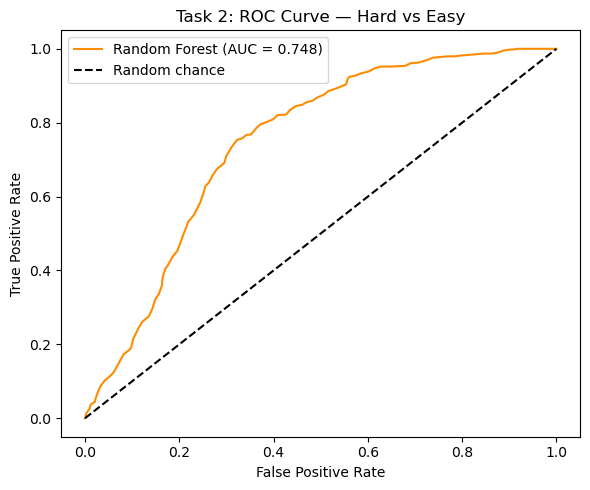

In [10]:
# confusion matrix and report for Task 2 using Random Forest (best model)
best_pipe2 = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", RandomForestClassifier(n_estimators=100, random_state=42))
])

all_y2_true = []
all_y2_pred = []
all_y2_prob = []

for train_idx, test_idx in cv.split(X2, y2, groups2):
    best_pipe2.fit(X2[train_idx], y2[train_idx])
    all_y2_true.extend(y2[test_idx])
    all_y2_pred.extend(best_pipe2.predict(X2[test_idx]))
    all_y2_prob.extend(best_pipe2.predict_proba(X2[test_idx])[:, 1])

# confusion matrix
cm2 = confusion_matrix(all_y2_true, all_y2_pred)
disp2 = ConfusionMatrixDisplay(cm2, display_labels=["Hard", "Easy"])
disp2.plot(cmap="Oranges")
plt.title("Task 2: Hard vs Easy — Confusion Matrix (Random Forest)")
plt.tight_layout()
plt.show()

print("\nClassification Report:")
print(classification_report(all_y2_true, all_y2_pred, target_names=["Hard", "Easy"]))

# ROC curve
fpr2, tpr2, _ = roc_curve(all_y2_true, all_y2_prob)
auc2 = roc_auc_score(all_y2_true, all_y2_prob)

plt.figure(figsize=(6, 5))
plt.plot(fpr2, tpr2, color="darkorange", label=f"Random Forest (AUC = {auc2:.3f})")
plt.plot([0, 1], [0, 1], "k--", label="Random chance")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Task 2: ROC Curve — Hard vs Easy")
plt.legend()
plt.tight_layout()
plt.show()

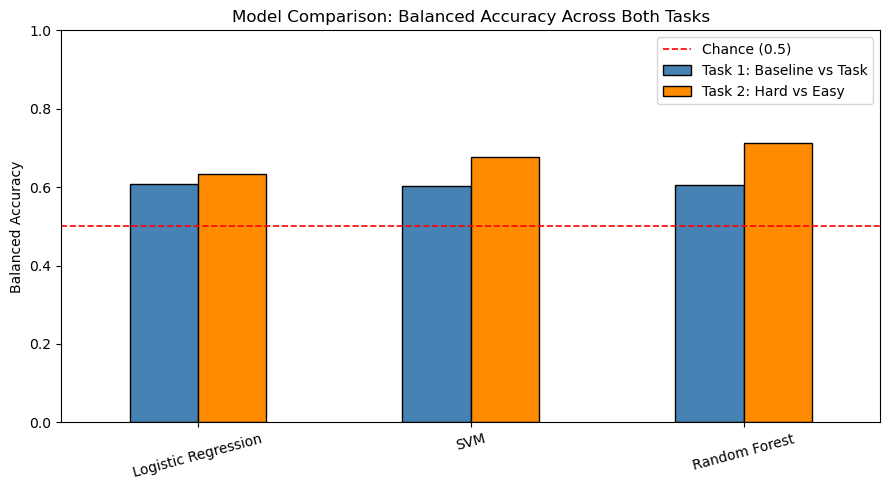


Summary Table:
Model                     Task1 BalAcc  Task1 AUC Task2 BalAcc  Task2 AUC
------------------------------------------------------------------------
Logistic Regression              0.609      0.705        0.634      0.717
SVM                              0.604      0.723        0.678      0.730
Random Forest                    0.604      0.755        0.713      0.769


In [11]:
# summary plot: both tasks side by side

task1_scores = {name: results[name]["bal_acc"].mean() for name in models}
task2_scores = {name: results2[name]["bal_acc"].mean() for name in models}

summary_df = pd.DataFrame({
    "Task 1: Baseline vs Task": task1_scores,
    "Task 2: Hard vs Easy":     task2_scores
})

ax = summary_df.plot(kind="bar", figsize=(9, 5), edgecolor="black",
                     color=["steelblue", "darkorange"])
plt.axhline(0.5, color="red", linestyle="--", linewidth=1.2, label="Chance (0.5)")
plt.ylabel("Balanced Accuracy")
plt.title("Model Comparison: Balanced Accuracy Across Both Tasks")
plt.xticks(rotation=15)
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()
plt.show()

# print a clean summary table
print("\nSummary Table:")
print(f"{'Model':<25} {'Task1 BalAcc':>12} {'Task1 AUC':>10} {'Task2 BalAcc':>12} {'Task2 AUC':>10}")
print("-" * 72)
for name in models:
    t1_acc = results[name]["bal_acc"].mean()
    t1_auc = results[name]["auc"].mean()
    t2_acc = results2[name]["bal_acc"].mean()
    t2_auc = results2[name]["auc"].mean()
    print(f"{name:<25} {t1_acc:>12.3f} {t1_auc:>10.3f} {t2_acc:>12.3f} {t2_auc:>10.3f}")

In [12]:
# save results summary
summary_data = []
for name in models:
    summary_data.append({
        "model":         name,
        "task1_bal_acc": round(results[name]["bal_acc"].mean(), 3),
        "task1_auc":     round(results[name]["auc"].mean(), 3),
        "task2_bal_acc": round(results2[name]["bal_acc"].mean(), 3),
        "task2_auc":     round(results2[name]["auc"].mean(), 3),
    })

results_df = pd.DataFrame(summary_data)

RESULTS_CSV = os.path.join(_root, "data", "eegmat", "model_results_summary.csv")
results_df.to_csv(RESULTS_CSV, index=False)

print("Results saved to:", RESULTS_CSV)
print("\nFinal Results:")
print(results_df.to_string(index=False))

Results saved to: /Users/anshpatel/Desktop/workload/data/eegmat/model_results_summary.csv

Final Results:
              model  task1_bal_acc  task1_auc  task2_bal_acc  task2_auc
Logistic Regression          0.609      0.705          0.634      0.717
                SVM          0.604      0.723          0.678      0.730
      Random Forest          0.604      0.755          0.713      0.769
